In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm




In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [4]:
data_dir = r"C:\Users\khaja\Downloads\Crop_Disease_March\Dataset\New Plant Diseases Dataset(Augmented)"

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    root=f"{data_dir}/train",
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_dataset = datasets.ImageFolder(
    root=f"{data_dir}/valid",
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

num_classes = len(train_dataset.classes)
print("Classes:", num_classes)


Classes: 1


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        self.fc1 = nn.Linear(32 * 16 * 16, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [6]:
model = SimpleCNN(num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [7]:
epochs = 5

for epoch in range(epochs):
    model.train()
    total = 0
    correct = 0
    running_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

        loop.set_postfix(
            loss=running_loss / total,
            acc=100 * correct / total
        )


Epoch 5/5: 100%|████████████████████████████████████████████████████| 126/126 [00:07<00:00, 16.91it/s, acc=100, loss=0]


Test Accuracy: 100.0


C:\Users\khaja\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


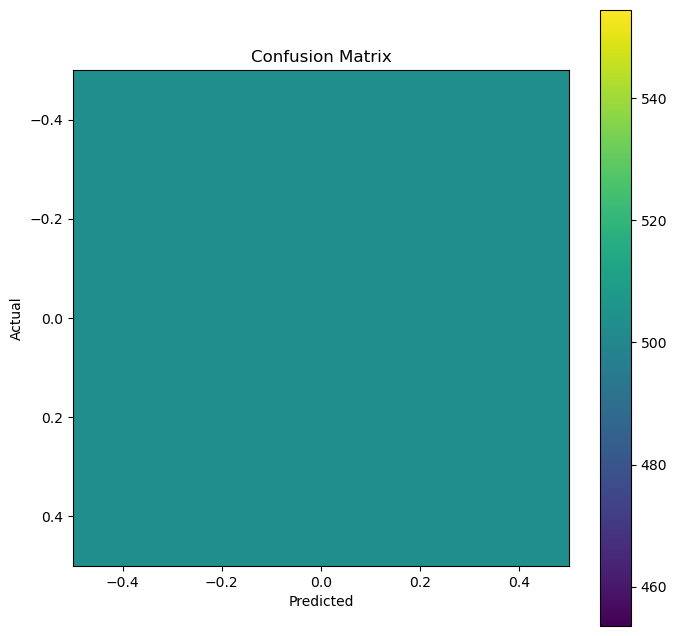

In [8]:
all_preds = []
all_labels = []
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
accuracy = 100 * correct / total
print("Test Accuracy:", accuracy)
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [21]:
torch.save(model.state_dict(), "new_model.pth")
print("Model saved successfully")


Model saved successfully


In [23]:
state = model.state_dict()
print(type(state))

<class 'collections.OrderedDict'>
